In [1]:
import keras
import tensorflow as tf
from pathlib import Path

# Load dataset
dataset_path = Path(r"D:/Amr/Portfolio/All time project/ready to publish/DL/Project 2/dataset")

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    validation_split=0.2,
    seed=42,
    batch_size=32,
    pad_to_aspect_ratio=True,
    subset='training',
    shuffle=True,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),
    seed=42,
    validation_split=0.2,
    batch_size=32,
    pad_to_aspect_ratio=True,
    subset='validation',
    shuffle=True,
)

Found 853 files belonging to 2 classes.
Using 683 files for training.
Found 853 files belonging to 2 classes.
Using 170 files for validation.


class names: ['with_masker', 'without_masker']


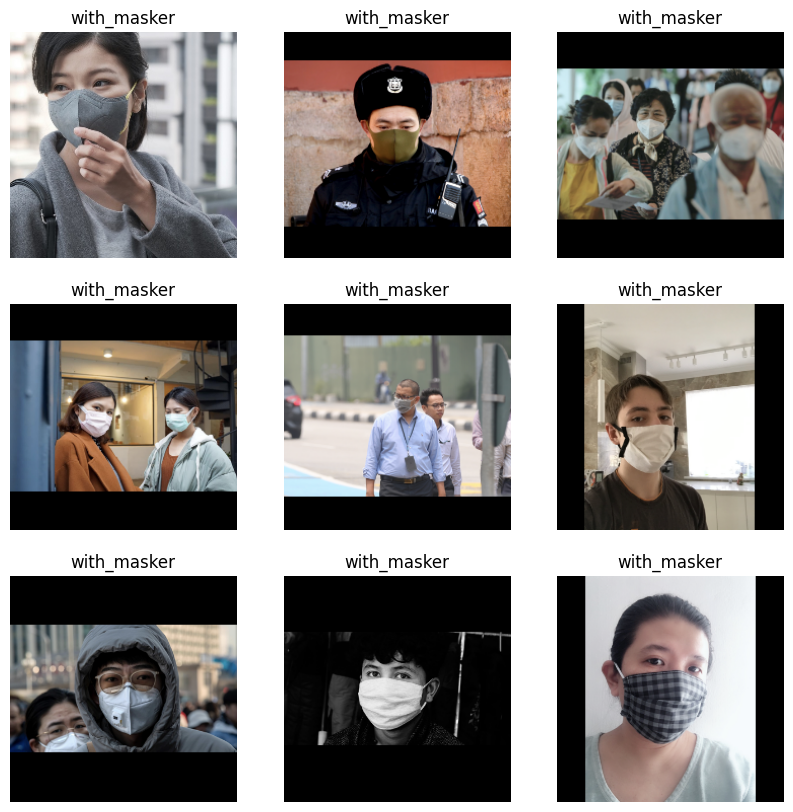

In [2]:
import matplotlib.pyplot as plt
print('class names:', train_ds.class_names)

# Show example of dataset
class_names = train_ds.class_names

images, labels = next(iter(train_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [4]:
# Normalize to [0,1]
train_ds = train_ds.map(lambda image, label: (image / 255.0, label))
val_ds = val_ds.map(lambda image, label: (image / 255.0, label))

# Checking result
for images, labels in train_ds.take(1):
    print(images.shape)



(32, 224, 224, 3)


In [5]:
import os

# Count how much each class
for folder in dataset_path.iterdir():
    if folder.is_dir():
        print(f"{folder.name}: {len(os.listdir(folder))} gambar")

without_masker: 39 gambar
with_masker: 814 gambar


The dataset is imbalanced, so we need to augment (oversample) the minority class so the training set is balanced.

In [6]:
from keras import Sequential, layers

# Augmentation
augment = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Unbatch so it can be filtered
train_ds_unbatched = train_ds.unbatch()

def count_samples(ds):
    return ds.reduce(0, lambda acc, _: acc + 1).numpy()

counts = {}
for idx in range(len(class_names)):
    ds_class = train_ds_unbatched.filter(lambda image, label, idx=idx: tf.equal(label, idx))
    counts[idx] = count_samples(ds_class)

majority_idx = max(counts, key=counts.get)
minority_idx = min(counts, key=counts.get)
majority_count = counts[majority_idx]
minority_count = counts[minority_idx]

def augment_fn(image, label):
    image = augment(tf.expand_dims(image, 0), training=True)[0]
    return image, label

majority_ds = train_ds_unbatched.filter(lambda image, label: tf.equal(label, majority_idx))
minority_ds = train_ds_unbatched.filter(lambda image, label: tf.equal(label, minority_idx))

# Oversample until the amount is equal
repeats = -(-majority_count // minority_count)  # ceil division
minority_oversampled = (
    minority_ds
    .repeat(repeats)
    .map(augment_fn)
    .take(majority_count)
)

balanced_ds = majority_ds.concatenate(minority_oversampled)
balanced_ds = balanced_ds.shuffle(buffer_size=majority_count * 2)

# Re-train batch
train_ds = balanced_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# Unbatch results
check_unbatched = train_ds.unbatch()

new_counts = {}
for idx in range(len(class_names)):
    ds_class = check_unbatched.filter(lambda image, label, idx=idx: tf.equal(label, idx))
    new_counts[idx] = count_samples(ds_class)

print(f"\nBefore -> {class_names[minority_idx]}: {minority_count}, {class_names[majority_idx]}: {majority_count}")
print(f"After -> {class_names[minority_idx]}: {new_counts[minority_idx]}, {class_names[majority_idx]}: {new_counts[majority_idx]}")


Before -> without_masker: 33, with_masker: 650
After -> without_masker: 650, with_masker: 650


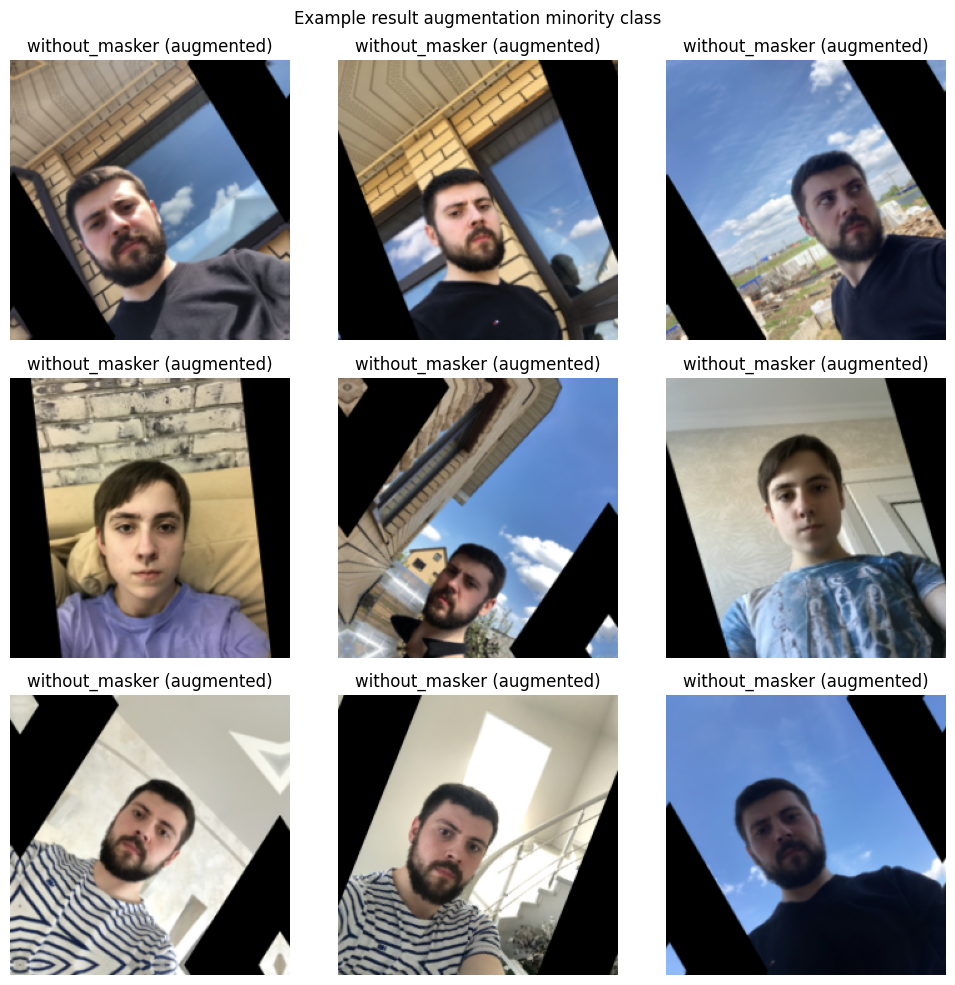

In [7]:
# Result after oversampling minor class
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(minority_oversampled.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{class_names[label.numpy()]} (augmented)")
    plt.axis("off")

plt.suptitle("Example result augmentation minority class")
plt.tight_layout()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1577088)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │   201,867,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,871,105 (770.08 MB)

 Trainable params: 201,871,105 (770.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
     41/Unknown 33s 644ms/step - accuracy: 0.7359 - loss: 11.4697

c:\Users\Fauzan Amrulloh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


41/41 ━━━━━━━━━━━━━━━━━━━━ 34s 658ms/step - accuracy: 0.8438 - loss: 5.3189 - val_accuracy: 0.9529 - val_loss: 0.5959
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 40s 839ms/step - accuracy: 0.9900 - loss: 0.0427 - val_accuracy: 0.9588 - val_loss: 0.5533
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 874ms/step - accuracy: 0.9969 - loss: 0.0172 - val_accuracy: 0.9353 - val_loss: 0.5333
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 878ms/step - accuracy: 0.9969 - loss: 0.0128 - val_accuracy: 0.9471 - val_loss: 0.3617
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 47s 887ms/step - accuracy: 0.9977 - loss: 0.0077 - val_accuracy: 0.9353 - val_loss: 0.3820
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 863ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.9412 - val_loss: 0.3833
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 862ms/step - accuracy: 1.0000 - loss: 8.1393e-04 - val_accuracy: 0.9471 - val_loss: 0.4947
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 863ms/step - accuracy: 0.9985 - loss: 0.0087 - val_accuracy: 0

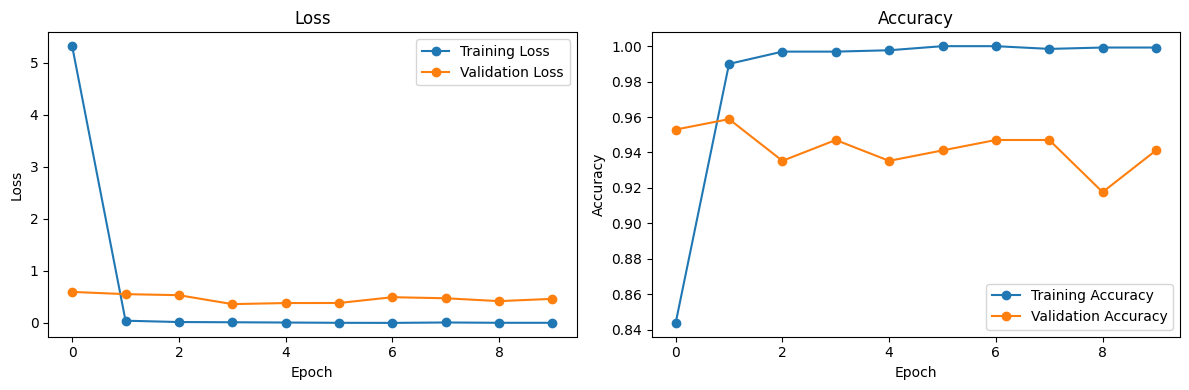

In [8]:
IMG_SIZE = 224

# Model
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D(2, 2),
    keras.layers.Dropout(0.25),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3), 
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Training using train_ds 
history = model.fit(train_ds, epochs=10, validation_data=val_ds,)

# Example predict 1 batch
sample_images, sample_labels = next(iter(train_ds))
predictions = model.predict(sample_images)
predicted_classes = (predictions > 0.5).astype(int).flatten()

# Visualize
# Visualize
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


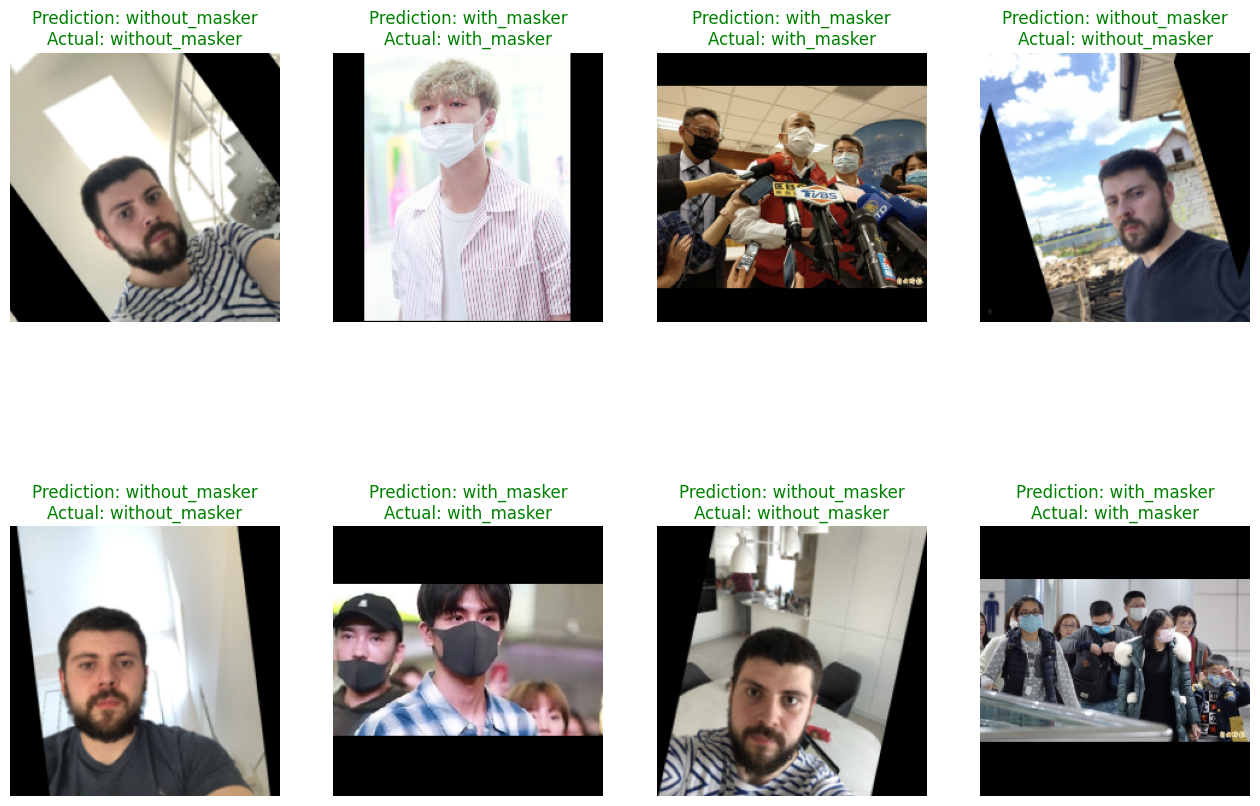

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Choose 1 batch from dataset 
sample_images, sample_labels = next(iter(train_ds))
predictions = model.predict(sample_images)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = sample_labels.numpy().flatten().astype(int)

# Show 8 images
show_images = min(8, len(sample_images))
cols = 4                                         
rows = (show_images + cols - 1) // cols   

# Scale up figsize
plt.figure(figsize=(16, 5 * rows))

for i in range(show_images):
    plt.subplot(rows, cols, i + 1)
    
    img = sample_images[i].numpy()
    if img.shape[-1] == 1:
        img = np.squeeze(img, axis=-1)
        plt.imshow(img, cmap='gray')
    else:
        if img.max() > 1.0:
            img = img.astype("uint8")
        plt.imshow(img)

    pred_name = class_names[predicted_classes[i]] 
    true_name = class_names[true_classes[i]]
    
    color = 'green' if true_classes[i] == predicted_classes[i] else 'red'
    
    plt.title(f"Prediction: {pred_name}\nActual: {true_name}", color=color, fontsize=12)
    plt.axis('off')

# Visualize
plt.subplots_adjust(hspace=0.6, wspace=0.2)
plt.show()